# SUPPORT2 EDA

Framingham の EDA ノートと同じ流れで、SUPPORT2 の元 CSV と ADMMHazardAFT 用に整形済みの `support2_inference.csv` を確認する。

見るポイント:

- 元データの列型、欠損、ユニーク値、分布
- `death` / `d.time` を用いた生存時間・イベント分布
- 疾患群、性別、人種、がん状態などのカテゴリ分布
- 既存の SUPPORT2 前処理で使う特徴量と、前処理後 long format の整合性

`death` は追跡期間中死亡フラグ、`hospdead` は入院中死亡フラグなので、生存解析では `death` と `d.time` を組にして見る。

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.4f}".format)

cwd = Path.cwd()
if (cwd / "support2.csv").exists():
    SUPPORT_DIR = cwd
    ROOT = SUPPORT_DIR.parents[2]
else:
    ROOT = cwd
    SUPPORT_DIR = ROOT / "data" / "real" / "support"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW_PATH = SUPPORT_DIR / "support2.csv"
INFERENCE_PATH = SUPPORT_DIR / "support2_inference.csv"
META_PATH = SUPPORT_DIR / "support2_inference.csv.meta.json"

raw = pd.read_csv(RAW_PATH, na_values=["NA"])
inference = pd.read_csv(INFERENCE_PATH) if INFERENCE_PATH.exists() else None
meta = json.loads(META_PATH.read_text(encoding="utf-8")) if META_PATH.exists() else {}

{
    "raw_path": str(RAW_PATH),
    "raw_shape": raw.shape,
    "inference_path": str(INFERENCE_PATH),
    "inference_shape": None if inference is None else inference.shape,
    "meta_available": bool(meta),
}

{'raw_path': '/Users/uminchu/GitHub/admm/data/real/support/support2.csv',
 'raw_shape': (9105, 47),
 'inference_path': '/Users/uminchu/GitHub/admm/data/real/support/support2_inference.csv',
 'inference_shape': (52992, 22),
 'meta_available': True}

## 1. 元データの概観

In [2]:
raw.head()

,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,totmcst,avtisst,race,sps,aps,surv2m,surv6m,hday,diabetes,dementia,ca,prg2m,prg6m,dnr,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,62.8500,0,male,0,5,2029,Lung Cancer,Cancer,0,11.0000,$11-$25k,0.0000,9715.0000,NaN,NaN,7.0000,other,33.8984,20.0000,0.2629,0.0370,1,0,0,metastatic,0.5000,0.2500,no dnr,5.0000,97.0000,6.0000,69.0000,22.0000,36.0000,388.0000,1.7998,0.2000,1.2000,141.0000,7.4600,NaN,NaN,NaN,7.0000,7.0000,NaN,7.0000
1,60.3390,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0000,$11-$25k,44.0000,34496.0000,NaN,NaN,29.0000,white,52.6953,74.0000,0.0010,0.0000,3,0,0,no,0.0000,0.0000,NaN,NaN,43.0000,17.0977,112.0000,34.0000,34.5938,98.0000,NaN,NaN,5.5000,132.0000,7.2500,NaN,NaN,NaN,NaN,1.0000,<2 mo. follow-up,1.0000
2,52.7470,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0000,under $11k,0.0000,41094.0000,NaN,NaN,13.0000,white,20.5000,45.0000,0.7909,0.6649,4,0,0,no,0.7500,0.5000,no dnr,17.0000,70.0000,8.5000,88.0000,28.0000,37.3984,231.6562,NaN,2.1997,2.0000,134.0000,7.4600,NaN,NaN,NaN,1.0000,0.0000,<2 mo. follow-up,0.0000
3,42.3850,1,female,0,3,133,Lung Cancer,Cancer,2,11.0000,under $11k,0.0000,3075.0000,NaN,NaN,7.0000,white,20.0977,19.0000,0.6990,0.4120,1,0,0,metastatic,0.9000,0.5000,no dnr,3.0000,75.0000,9.0996,88.0000,32.0000,35.0000,NaN,NaN,NaN,0.7999,139.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,no(M2 and SIP pres),0.0000
4,79.8849,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0000,50127.0000,NaN,NaN,18.6667,white,23.5000,30.0000,0.6349,0.5330,3,0,0,no,0.9000,0.9000,no dnr,16.0000,59.0000,13.5000,112.0000,20.0000,37.8984,173.3125,NaN,NaN,0.7999,143.0000,7.5098,NaN,NaN,NaN,NaN,2.0000,no(M2 and SIP pres),2.0000


In [3]:
profile = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "n_missing": raw.isna().sum(),
        "missing_rate": raw.isna().mean(),
        "n_unique": raw.nunique(dropna=True),
    }
).sort_values(["missing_rate", "n_missing"], ascending=False)

profile

,dtype,n_missing,missing_rate,n_unique
adlp,float64,5641,0.6195,8
urine,float64,4862,0.5340,1494
glucose,float64,4500,0.4942,439
bun,float64,4352,0.4780,159
totmcst,float64,3475,0.3817,5516
alb,float64,3372,0.3703,60
income,object,2982,0.3275,4
adls,float64,2867,0.3149,8
bili,float64,2601,0.2857,295
pafi,float64,2325,0.2554,1457


In [4]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,9105.0000,NaN,NaN,NaN,62.6508,15.5937,18.0420,52.7970,64.8570,73.9990,101.8480
death,9105.0000,NaN,NaN,NaN,0.6811,0.4661,0.0000,0.0000,1.0000,1.0000,1.0000
sex,9105,2,male,5125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hospdead,9105.0000,NaN,NaN,NaN,0.2592,0.4382,0.0000,0.0000,0.0000,1.0000,1.0000
slos,9105.0000,NaN,NaN,NaN,17.8630,22.0064,3.0000,6.0000,11.0000,20.0000,343.0000
d.time,9105.0000,NaN,NaN,NaN,478.4499,560.3833,3.0000,26.0000,233.0000,761.0000,2029.0000
dzgroup,9105,8,ARF/MOSF w/Sepsis,3515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dzclass,9105,4,ARF/MOSF,4227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num.co,9105.0000,NaN,NaN,NaN,1.8686,1.3444,0.0000,1.0000,2.0000,3.0000,9.0000
edu,7471.0000,NaN,NaN,NaN,11.7477,3.4477,0.0000,10.0000,12.0000,14.0000,31.0000


In [5]:
# Framingham ノートと同じく、各列のユニーク値数を一覧する。
for col in raw.columns:
    print(f"{col}: {raw[col].nunique(dropna=True)}")

age: 7323
death: 2
sex: 2
hospdead: 2
slos: 167
d.time: 1724
dzgroup: 8
dzclass: 4
num.co: 10
edu: 31
income: 4
scoma: 11
charges: 8501
totcst: 8197
totmcst: 5516
avtisst: 352
race: 5
sps: 604
aps: 125
surv2m: 949
surv6m: 936
hday: 85
diabetes: 2
dementia: 2
ca: 3
prg2m: 51
prg6m: 88
dnr: 3
dnrday: 177
meanbp: 164
wblc: 499
hrt: 186
resp: 66
temp: 98
pafi: 1457
alb: 60
bili: 295
crea: 130
sod: 60
ph: 77
glucose: 439
bun: 159
urine: 1494
adlp: 8
adls: 8
sfdm2: 5
adlsc: 1735


## 2. カテゴリ変数の分布

In [6]:
categorical_cols = raw.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

for col in categorical_cols:
    print(f"\n## {col}")
    display(
        raw[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
        .assign(rate=lambda d: d["count"] / len(raw))
    )


## sex


,sex,count,rate
0,male,5125,0.5629
1,female,3980,0.4371



## dzgroup


,dzgroup,count,rate
0,ARF/MOSF w/Sepsis,3515,0.3861
1,CHF,1387,0.1523
2,COPD,967,0.1062
3,Lung Cancer,908,0.0997
4,MOSF w/Malig,712,0.0782
5,Coma,596,0.0655
6,Colon Cancer,512,0.0562
7,Cirrhosis,508,0.0558



## dzclass


...

,ca,count,rate
0,no,5995,0.6584
1,metastatic,1858,0.2041
2,yes,1252,0.1375



## dnr


,dnr,count,rate
0,no dnr,5880,0.6458
1,dnr after sadm,2956,0.3247
2,dnr before sadm,239,0.0262
3,NaN,30,0.0033



## sfdm2


,sfdm2,count,rate
0,<2 mo. follow-up,3123,0.3430
1,no(M2 and SIP pres),3061,0.3362
2,NaN,1400,0.1538
3,adl>=4 (>=5 if sur),916,0.1006
4,SIP>=30,564,0.0619
5,Coma or Intub,41,0.0045


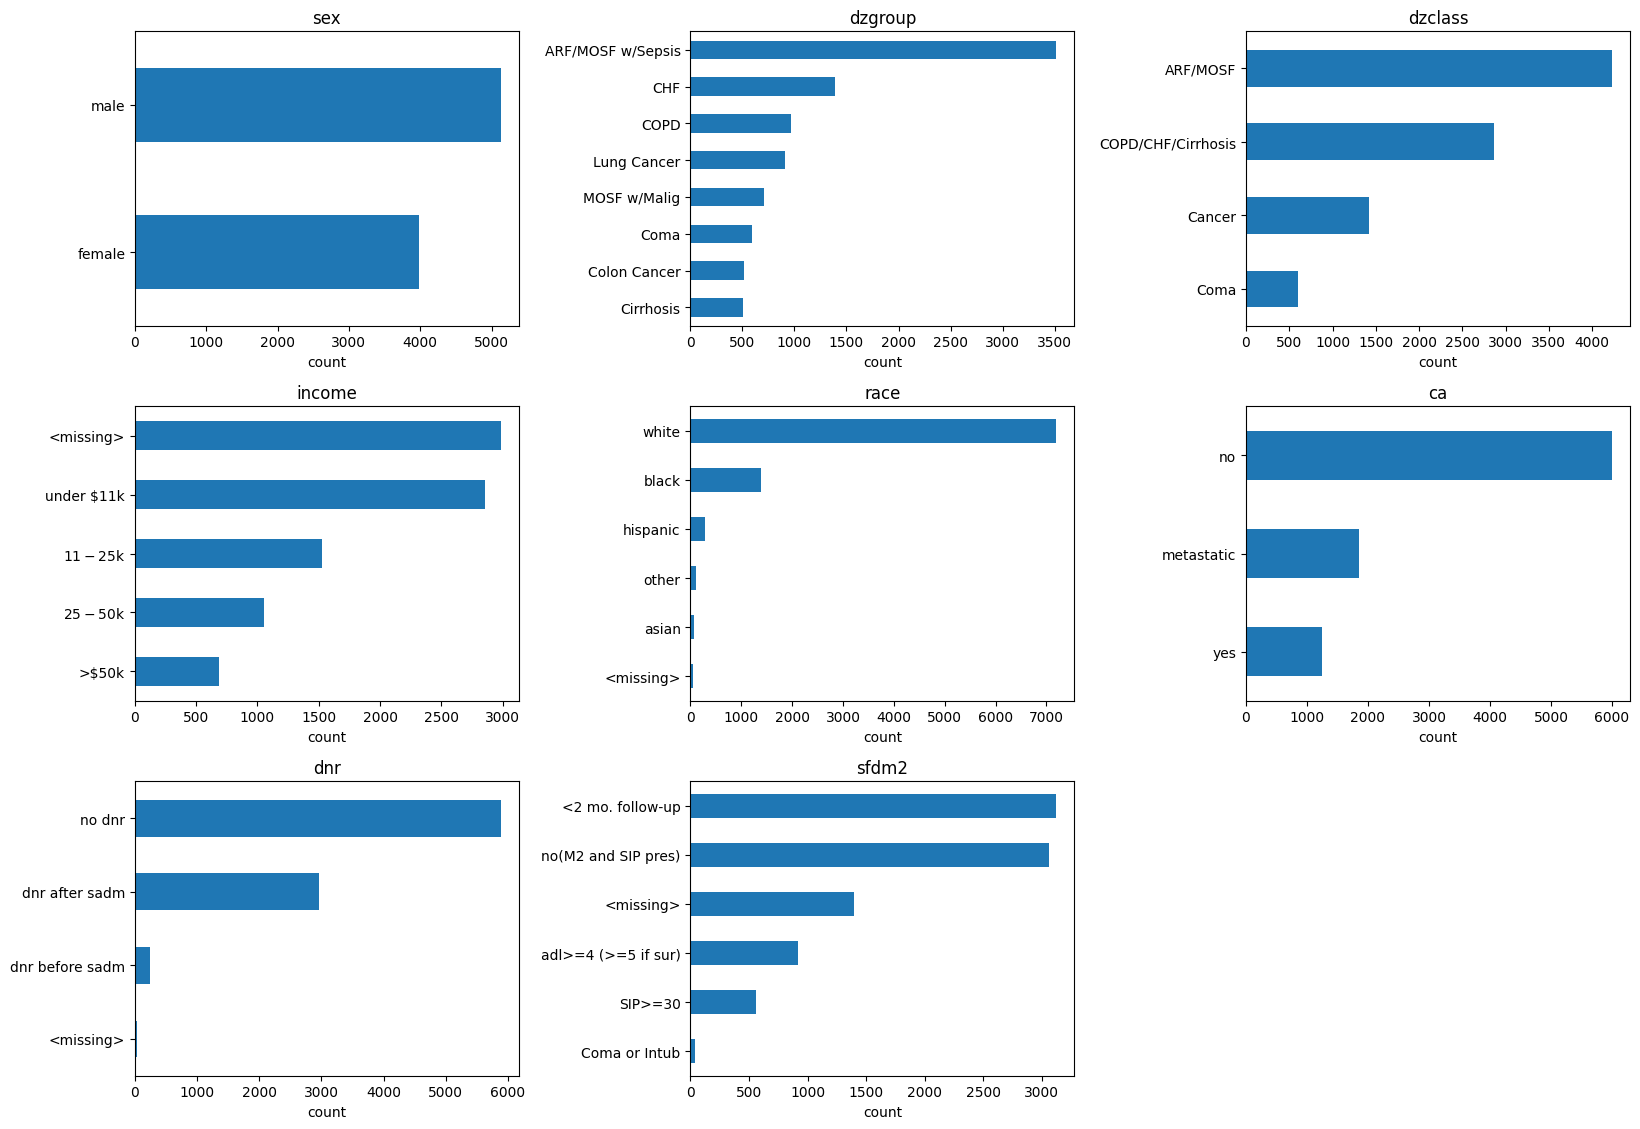

In [7]:
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.8 * n_rows))
axes = np.asarray(axes).ravel()

for ax, col in zip(axes, categorical_cols):
    counts = raw[col].fillna("<missing>").value_counts().head(12).sort_values()
    counts.plot.barh(ax=ax)
    ax.set_title(col)
    ax.set_xlabel("count")
    ax.set_ylabel("")

for ax in axes[len(categorical_cols) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 3. 欠損の確認

SUPPORT2 は検査値やコスト系列に欠損が多い。モデル用の既存前処理では、使用する raw 特徴量に欠損がある症例を除外する。

In [8]:
missing = profile.loc[
    profile["n_missing"] > 0, ["n_missing", "missing_rate", "n_unique"]
]
missing

,n_missing,missing_rate,n_unique
adlp,5641,0.6195,8
urine,4862,0.5340,1494
glucose,4500,0.4942,439
bun,4352,0.4780,159
totmcst,3475,0.3817,5516
alb,3372,0.3703,60
income,2982,0.3275,4
adls,2867,0.3149,8
bili,2601,0.2857,295
pafi,2325,0.2554,1457


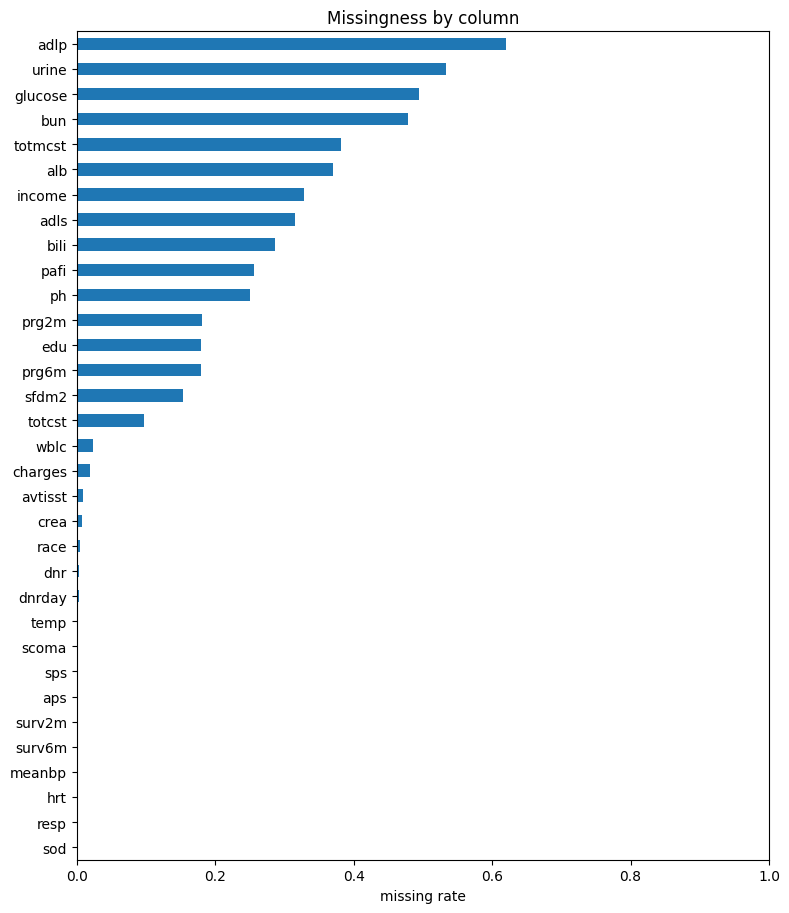

In [9]:
plot_missing = missing.sort_values("missing_rate")
fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(plot_missing))))
plot_missing["missing_rate"].plot.barh(ax=ax)
ax.set_xlabel("missing rate")
ax.set_xlim(0, 1)
ax.set_title("Missingness by column")
plt.tight_layout()
plt.show()

## 4. 数値列の分布

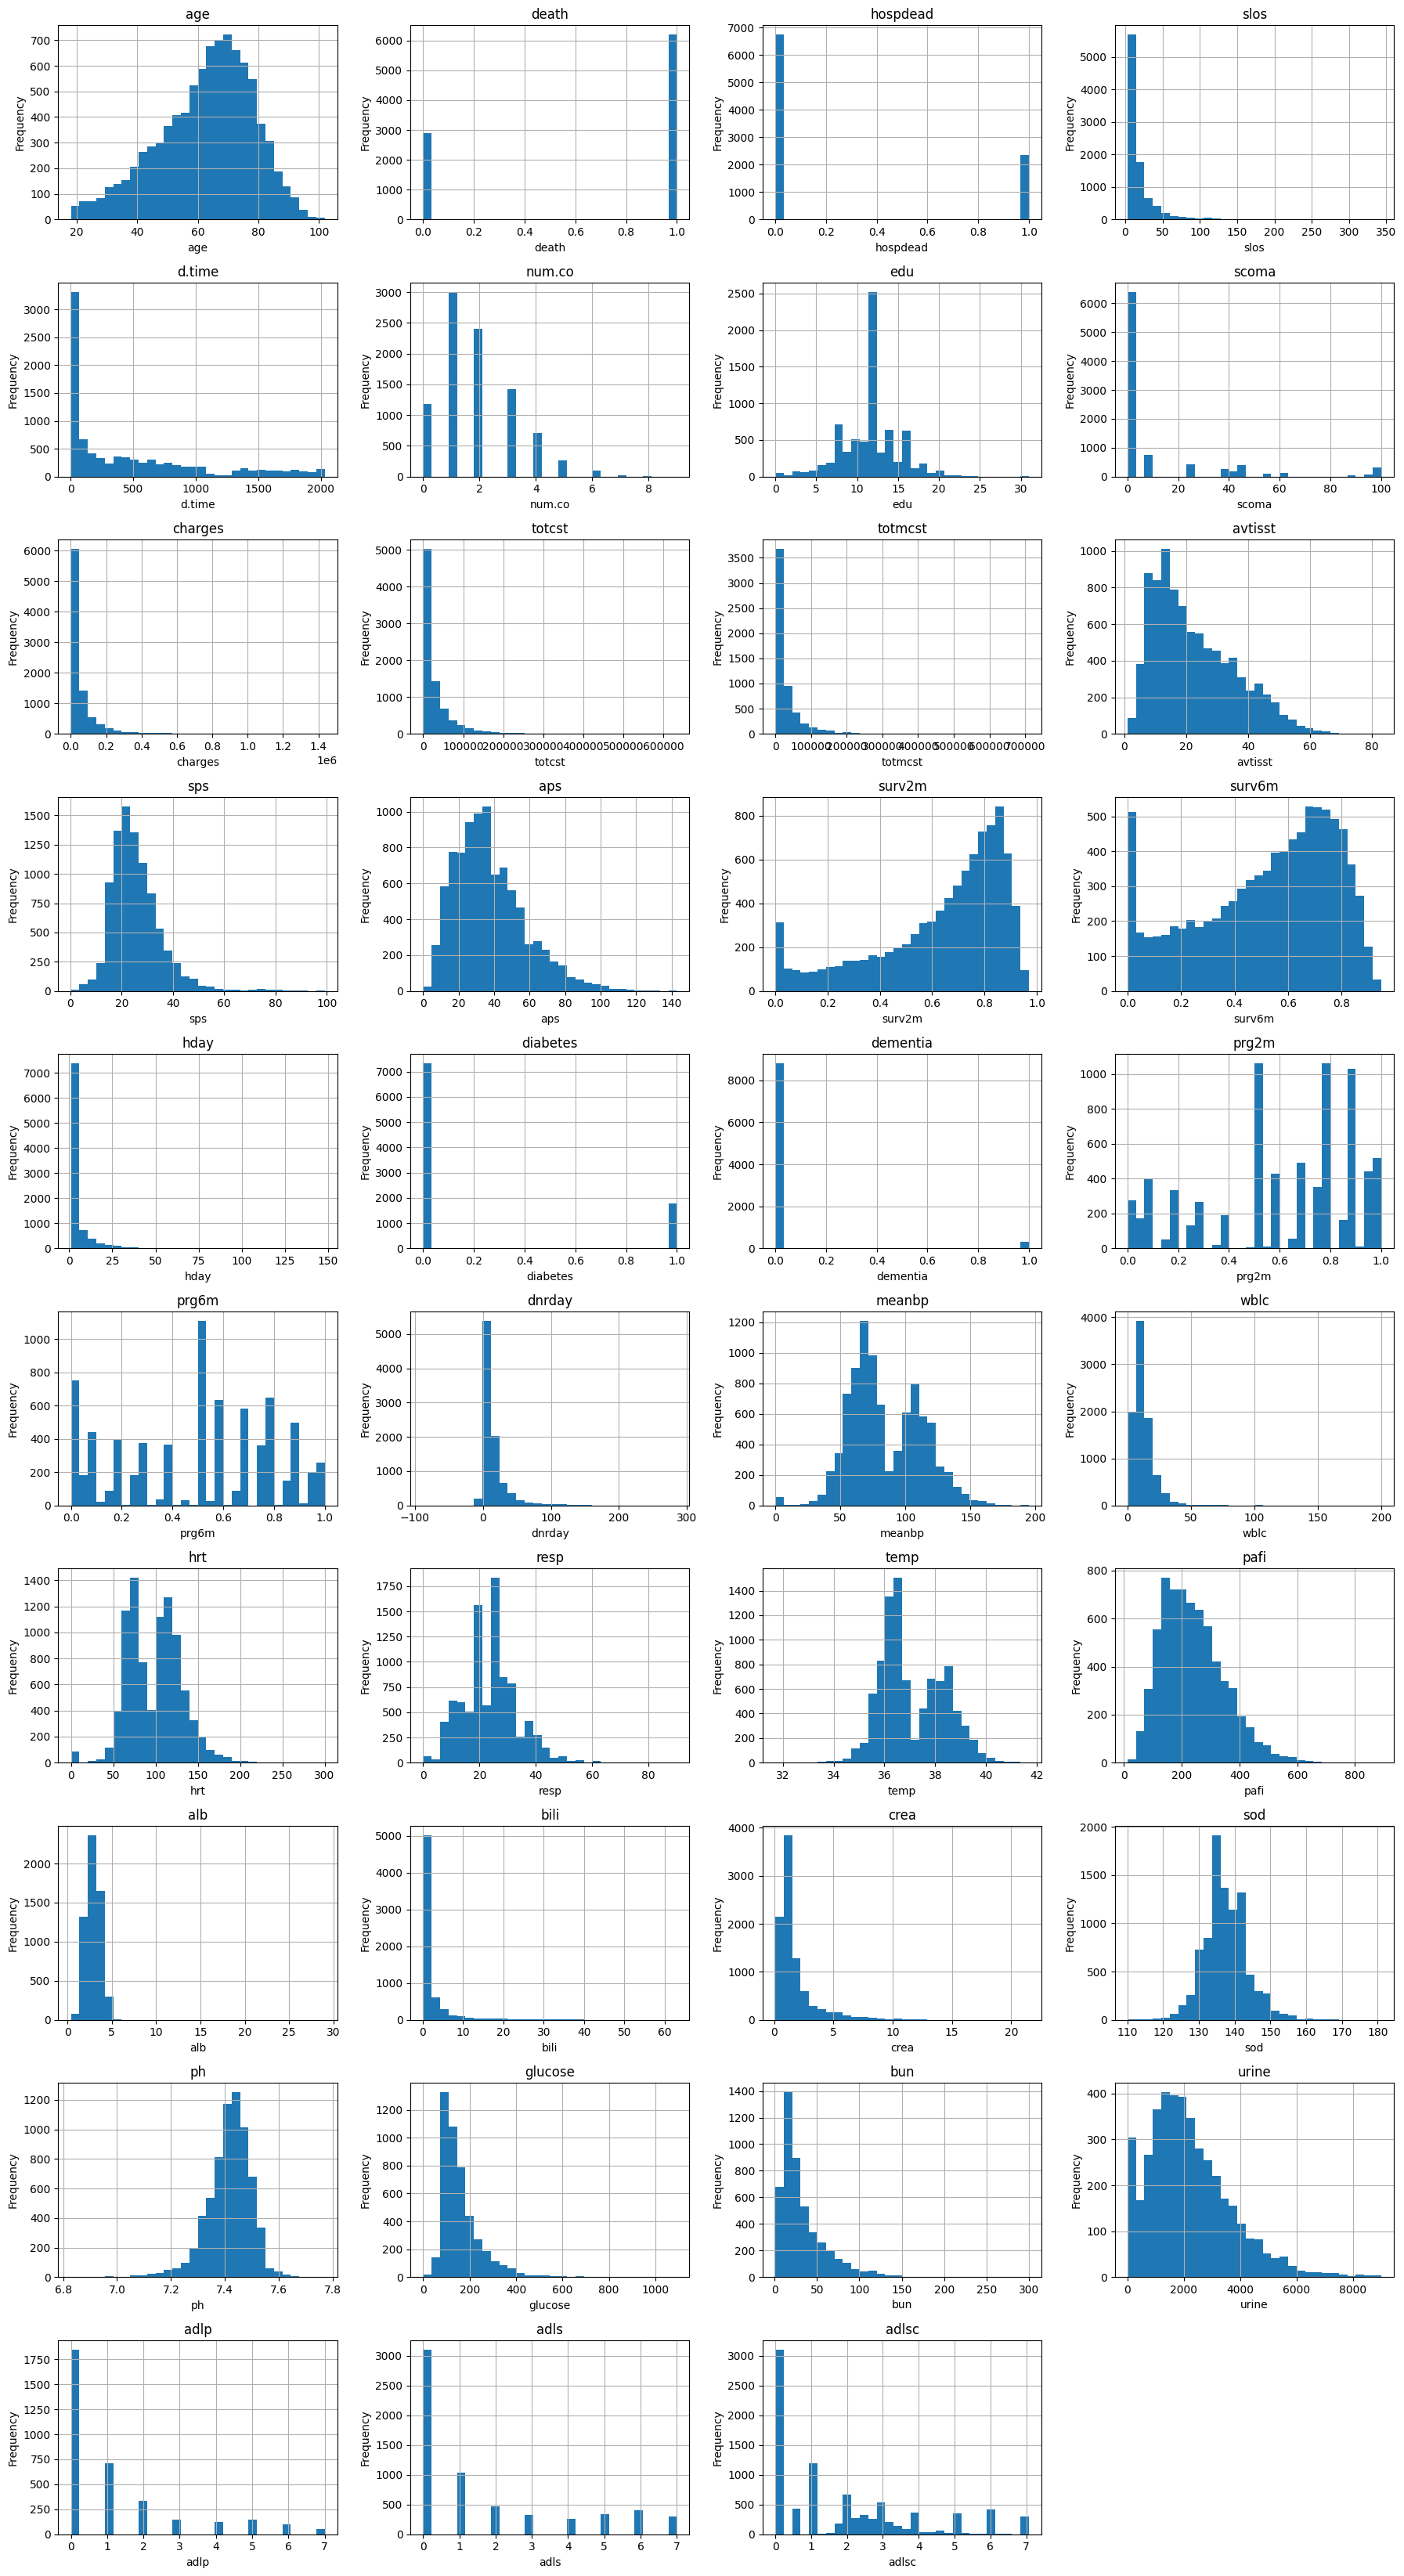

In [ ]:
numeric_cols = raw.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.3 * n_rows))
axes = np.asarray(axes).ravel()

for ax, col in zip(axes, numeric_cols):
    raw[col].dropna().hist(ax=ax, bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(numeric_cols) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 5. 生存時間・イベントの確認

In [11]:
event_summary = pd.DataFrame(
    {
        "count": raw["death"].value_counts(dropna=False).sort_index(),
    }
)
event_summary["rate"] = event_summary["count"] / event_summary["count"].sum()
event_summary.index = event_summary.index.map(
    {0: "censored/death=0", 1: "event/death=1"}
)
event_summary

,count,rate
death,,
censored/death=0,2904,0.3189
event/death=1,6201,0.6811


In [12]:
raw[["d.time", "death", "hospdead", "slos"]].describe().T

,count,mean,std,min,25%,50%,75%,max
d.time,9105.0000,478.4499,560.3833,3.0000,26.0000,233.0000,761.0000,2029.0000
death,9105.0000,0.6811,0.4661,0.0000,0.0000,1.0000,1.0000,1.0000
hospdead,9105.0000,0.2592,0.4382,0.0000,0.0000,0.0000,1.0000,1.0000
slos,9105.0000,17.8630,22.0064,3.0000,6.0000,11.0000,20.0000,343.0000


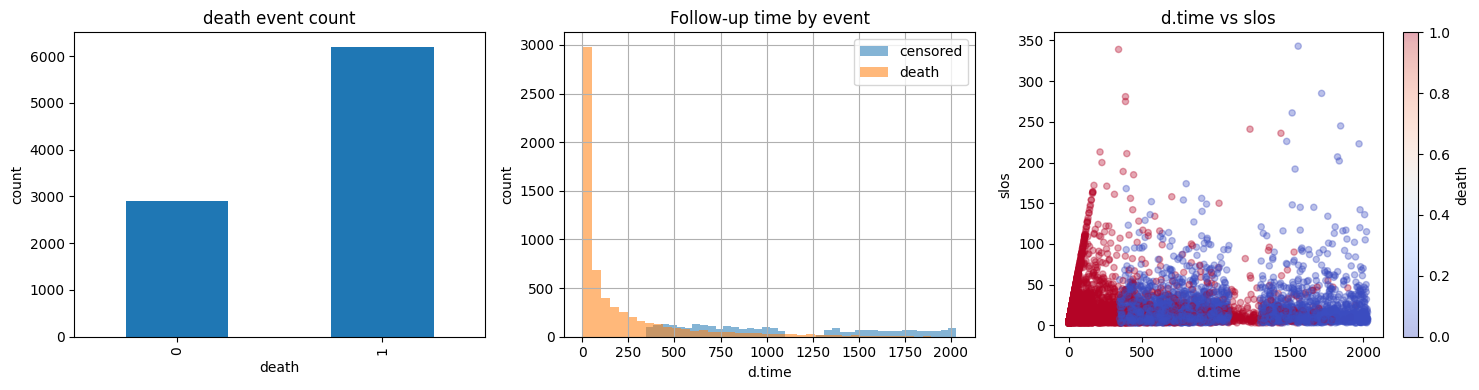

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

raw["death"].value_counts().sort_index().plot.bar(ax=axes[0])
axes[0].set_title("death event count")
axes[0].set_xlabel("death")
axes[0].set_ylabel("count")

for value, label in [(0, "censored"), (1, "death")]:
    raw.loc[raw["death"] == value, "d.time"].dropna().hist(
        ax=axes[1], bins=40, alpha=0.55, label=label
    )
axes[1].set_title("Follow-up time by event")
axes[1].set_xlabel("d.time")
axes[1].set_ylabel("count")
axes[1].legend()

raw.plot.scatter(
    x="d.time", y="slos", c="death", cmap="coolwarm", alpha=0.35, ax=axes[2]
)
axes[2].set_title("d.time vs slos")
axes[2].set_xlabel("d.time")
axes[2].set_ylabel("slos")

plt.tight_layout()
plt.show()

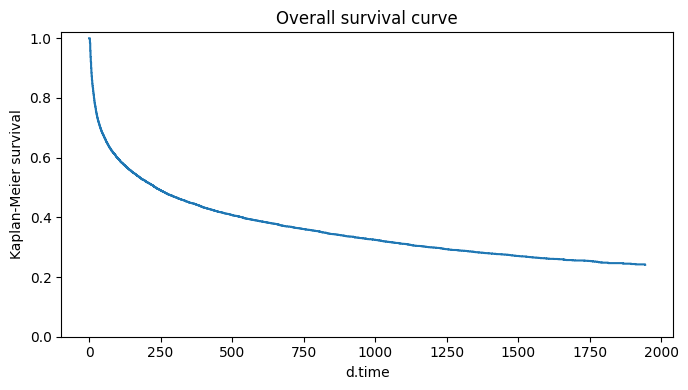

,time,survival,n_risk,n_events
1037,1866.0000,0.2457,265,1
1038,1868.0000,0.2448,256,1
1039,1895.0000,0.2436,217,1
1040,1910.0000,0.2424,201,1
1041,1944.0000,0.2409,157,1


In [14]:
def kaplan_meier_table(time, event):
    """外部依存なしで Kaplan-Meier 曲線用の表を作る。"""
    km = pd.DataFrame({"time": time, "event": event}).dropna().sort_values("time")
    event_times = np.sort(km.loc[km["event"] == 1, "time"].unique())
    n = len(km)
    surv = 1.0
    rows = [{"time": 0.0, "survival": 1.0, "n_risk": n, "n_events": 0}]
    for t in event_times:
        at_risk = int((km["time"] >= t).sum())
        n_events = int(((km["time"] == t) & (km["event"] == 1)).sum())
        if at_risk > 0:
            surv *= 1.0 - n_events / at_risk
        rows.append(
            {
                "time": float(t),
                "survival": surv,
                "n_risk": at_risk,
                "n_events": n_events,
            }
        )
    return pd.DataFrame(rows)


km = kaplan_meier_table(raw["d.time"], raw["death"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.step(km["time"], km["survival"], where="post")
ax.set_ylim(0, 1.02)
ax.set_xlabel("d.time")
ax.set_ylabel("Kaplan-Meier survival")
ax.set_title("Overall survival curve")
plt.tight_layout()
plt.show()

km.tail()

def summarize_event_by_category(df, col, event_col="death"):
    tab = (
        df.groupby(col, dropna=False)[event_col]
        .agg(n="size", event_rate="mean", n_events="sum")
        .sort_values("n", ascending=False)
    )
    return tab

for col in ["dzclass", "dzgroup", "sex", "race", "ca", "income", "dnr"]:
    print(f"\n## {col}")
    display(summarize_event_by_category(raw, col))

In [15]:
def summarize_event_by_category(df, col, event_col="death"):
    tab = (
        df.groupby(col, dropna=False)[event_col]
        .agg(n="size", event_rate="mean", n_events="sum")
        .sort_values("n", ascending=False)
    )
    return tab


for col in ["dzclass", "dzgroup", "sex", "race", "ca", "income", "dnr"]:
    print(f"\n## {col}")
    display(summarize_event_by_category(raw, col))


## dzclass


,n,event_rate,n_events
dzclass,,,
ARF/MOSF,4227,0.6442,2723
COPD/CHF/Cirrhosis,2862,0.6059,1734
Cancer,1420,0.8873,1260
Coma,596,0.8121,484



## dzgroup


,n,event_rate,n_events
dzgroup,,,
ARF/MOSF w/Sepsis,3515,0.5906,2076
CHF,1387,0.6085,844
COPD,967,0.5801,561
Lung Cancer,908,0.9174,833
MOSF w/Malig,712,0.9087,647
Coma,596,0.8121,484
Colon Cancer,512,0.8340,427
Cirrhosis,508,0.6476,329



## sex


...

,n,event_rate,n_events
ca,,,
no,5995,0.5988,3590
metastatic,1858,0.8929,1659
yes,1252,0.7604,952



## income


,n,event_rate,n_events
income,,,
NaN,2982,0.7096,2116
under $11k,2855,0.6736,1923
$11-$25k,1527,0.6660,1017
$25-$50k,1057,0.6594,697
>$50k,684,0.6550,448



## dnr


,n,event_rate,n_events
dnr,,,
no dnr,5880,0.5514,3242
dnr after sadm,2956,0.9263,2738
dnr before sadm,239,0.8410,201
NaN,30,0.6667,20


In [16]:
cols = [
    "age",
    "sps",
    "aps",
    "surv2m",
    "surv6m",
    "prg2m",
    "prg6m",
    "meanbp",
    "hrt",
    "resp",
    "crea",
]
summary_by_event = raw.groupby("death")[cols].agg(["count", "mean", "std", "median"])
summary_by_event

age                           sps                           aps  \
      count    mean     std  median count    mean     std  median count   
death                                                                     
0      2904 58.5670 16.6603 60.7625  2904 23.2645  7.0726 22.5977  2904   
1      6201 64.5633 14.6842 66.2040  6200 26.5851 10.8149 24.7969  6200   

                              surv2m                      surv6m         \
         mean     std  median  count   mean    std median  count   mean   
death                                                                     
0     33.0362 15.6203 31.0000   2904 0.7537 0.1628 0.8019   2904 0.6601   
1     39.7347 21.2879 36.0000   6200 0.5807 0.2617 0.6570   6200 0.4545   

                    prg2m                      prg6m                       \
         std median count   mean    std median count   mean    std median   
death                                                                       
0     0.1857 0.7059  2394 0.7519 0.2241 0.8000  2397 0.6696 0.2456 0.7000   
1     0.2542 0.4895  5062 0.5558 0.3083 0.6000  5075 0.4194 0.2964 0.5000   

      meanbp                           hrt                           resp  \
       count    mean     std  median count    mean     std   median count   
death                                                                       
0       2904 85.8309 27.3167 78.0000  2904 97.3338 31.2468 100.0000  2904   
1       6200 83.9448 27.8416 77.0000  6200 97.0738 31.7068 100.0000  6200   

                              crea                       
         mean    std  median count   mean    std median  
death                                                    
0     23.2417 9.5934 24.0000  2889 1.7053 1.6813 1.2000  
1     23.3718 9.5651 24.0000  6149 1.8018 1.6875 1.2000

## 7. ADMMHazardAFT 用前処理との対応

実験用の SUPPORT2 前処理は `data/real/support/prepare_support2_inference.py` と `scripts/real_cv/datasets.py` に集約されている。ここでは同じ loader を使って、1 患者 1 行の base data と long format CSV の整合性を見る。

In [17]:
from scripts.real_cv.datasets import get_dataset_spec, load_real_base

spec = get_dataset_spec("support2")
base = load_real_base("support2", RAW_PATH)

{
    "raw_rows": len(raw),
    "base_subjects_after_preprocessing": len(base),
    "dropped_rows": len(raw) - len(base),
    "event_count": int(base["event_original"].sum()),
    "censored_count": int((base["event_original"] == 0).sum()),
    "feature_count": len(spec.feature_cols),
    "feature_cols": spec.feature_cols,
    "continuous_feature_cols": spec.continuous_feature_cols,
    "categorical_reference_levels": spec.categorical_reference_levels,
}

{'raw_rows': 9105,
 'base_subjects_after_preprocessing': 8832,
 'dropped_rows': 273,
 'event_count': 6005,
 'censored_count': 2827,
 'feature_count': 18,
 'feature_cols': ['age',
  'sex_male',
  'race_black',
  'race_hispanic',
  'race_asian',
  'race_other',
  'num.co',
  'diabetes',
  'dementia',
  'ca_yes',
  'ca_metastatic',
  'meanbp',
  'hrt',
  'resp',
  'temp',
  'wblc',
  'sod',
  'crea'],
 'continuous_feature_cols': ['age',
  'num.co',
  'meanbp',
  'hrt',
  'resp',
  'temp',
  'wblc',
  'sod',
  'crea'],
 'categorical_reference_levels': {'sex': 'female',
  'race': 'white',
  'ca': 'no'}}

In [18]:
base.head()

,id,time_original,event_original,age,sex_male,race_black,race_hispanic,race_asian,race_other,num.co,diabetes,dementia,ca_yes,ca_metastatic,meanbp,hrt,resp,temp,wblc,sod,crea
0,1,2029.0000,0,62.8500,1,0,0,0,1,0,0,0,0,1,97.0000,69.0000,22.0000,36.0000,6.0000,141.0000,1.2000
1,2,4.0000,1,60.3390,0,0,0,0,0,2,0,0,0,0,43.0000,112.0000,34.0000,34.5938,17.0977,132.0000,5.5000
2,3,47.0000,1,52.7470,0,0,0,0,0,2,0,0,0,0,70.0000,88.0000,28.0000,37.3984,8.5000,134.0000,2.0000
3,4,133.0000,1,42.3850,0,0,0,0,0,2,0,0,0,1,75.0000,88.0000,32.0000,35.0000,9.0996,139.0000,0.7999
4,5,2029.0000,0,79.8849,0,0,0,0,0,1,0,0,0,0,59.0000,112.0000,20.0000,37.8984,13.5000,143.0000,0.7999


In [19]:
base[["time_original", "event_original", *spec.feature_cols]].describe().T

,count,mean,std,min,25%,50%,75%,max
time_original,8832.0000,478.8825,560.6279,3.0000,26.0000,233.0000,763.2500,2029.0000
event_original,8832.0000,0.6799,0.4665,0.0000,0.0000,1.0000,1.0000,1.0000
age,8832.0000,62.6258,15.6197,18.0420,52.7537,64.8450,74.0290,101.8480
sex_male,8832.0000,0.5630,0.4960,0.0000,0.0000,1.0000,1.0000,1.0000
race_black,8832.0000,0.1546,0.3615,0.0000,0.0000,0.0000,0.0000,1.0000
race_hispanic,8832.0000,0.0320,0.1761,0.0000,0.0000,0.0000,0.0000,1.0000
race_asian,8832.0000,0.0086,0.0924,0.0000,0.0000,0.0000,0.0000,1.0000
race_other,8832.0000,0.0125,0.1109,0.0000,0.0000,0.0000,0.0000,1.0000
num.co,8832.0000,1.8698,1.3428,0.0000,1.0000,2.0000,3.0000,9.0000
diabetes,8832.0000,0.1947,0.3960,0.0000,0.0000,0.0000,0.0000,1.0000


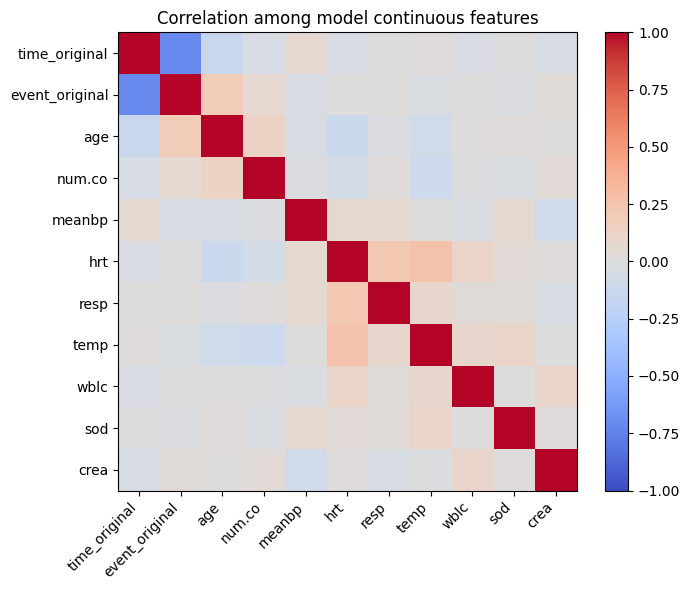

,time_original,event_original,age,num.co,meanbp,hrt,resp,temp,wblc,sod,crea
time_original,1.0000,-0.7105,-0.1345,-0.0471,0.0579,-0.0389,-0.0023,0.0079,-0.0388,-0.0003,-0.0452
event_original,-0.7105,1.0000,0.1799,0.0674,-0.0338,-0.0041,0.0065,-0.0298,-0.0047,-0.0177,0.0272
age,-0.1345,0.1799,1.0000,0.1286,-0.0416,-0.1287,-0.0216,-0.0872,0.0027,0.0137,0.0022
num.co,-0.0471,0.0674,0.1286,1.0000,-0.0199,-0.0682,0.0081,-0.1143,-0.0118,-0.0240,0.0343
meanbp,0.0579,-0.0338,-0.0416,-0.0199,1.0000,0.0675,0.0640,0.0013,-0.0292,0.0634,-0.0810
hrt,-0.0389,-0.0041,-0.1287,-0.0682,0.0675,1.0000,0.2119,0.2643,0.1153,0.0336,0.0094
resp,-0.0023,0.0065,-0.0216,0.0081,0.0640,0.2119,1.0000,0.0870,0.0306,0.0258,-0.0414
temp,0.0079,-0.0298,-0.0872,-0.1143,0.0013,0.2643,0.0870,1.0000,0.0919,0.1135,-0.0099
wblc,-0.0388,-0.0047,0.0027,-0.0118,-0.0292,0.1153,0.0306,0.0919,1.0000,0.0066,0.1020
sod,-0.0003,-0.0177,0.0137,-0.0240,0.0634,0.0336,0.0258,0.1135,0.0066,1.0000,0.0126


In [20]:
corr_cols = ["time_original", "event_original", *spec.continuous_feature_cols]
corr = base[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation among model continuous features")
plt.tight_layout()
plt.show()

corr

## 8. long format CSV の整合性チェック

In [21]:
if inference is None:
    raise FileNotFoundError(INFERENCE_PATH)

feature_cols = [
    col for col in inference.columns if col not in {"id", "k", "time", "event"}
]
rows_per_id = inference.groupby("id").size()
k_per_id = inference.groupby("id")["k"].nunique()
expected_K = int(meta.get("K", k_per_id.iloc[0]))

checks = pd.Series(
    {
        "n_rows": len(inference),
        "n_subjects": inference["id"].nunique(),
        "expected_K": expected_K,
        "all_ids_have_K_rows": bool((rows_per_id == expected_K).all()),
        "all_ids_have_K_unique_k": bool((k_per_id == expected_K).all()),
        "k_min": int(inference["k"].min()),
        "k_max": int(inference["k"].max()),
        "time_min": float(inference["time"].min()),
        "time_max": float(inference["time"].max()),
        "event_values": sorted(inference["event"].unique().tolist()),
        "any_missing": bool(inference.isna().any().any()),
        "feature_count": len(feature_cols),
    }
)
checks

n_rows                      52992
n_subjects                   8832
expected_K                      6
all_ids_have_K_rows          True
all_ids_have_K_unique_k      True
k_min                           0
k_max                           5
time_min                   0.0089
time_max                   6.0000
event_values               [0, 1]
any_missing                 False
feature_count                  18
dtype: object

In [22]:
# 時間依存共変量は持たせず、各 id で全 k に同じ特徴量を繰り返していることを確認する。
feature_nunique_max = (
    inference.groupby("id")[feature_cols].nunique().max().sort_values(ascending=False)
)
feature_nunique_max

age              1
sex_male         1
sod              1
wblc             1
temp             1
resp             1
hrt              1
meanbp           1
ca_metastatic    1
ca_yes           1
dementia         1
diabetes         1
num.co           1
race_other       1
race_asian       1
race_hispanic    1
race_black       1
crea             1
dtype: int64

In [23]:
# long format では各 id が K 行あるため、イベント数は K で割って患者数ベースに戻す。
inference_subject = inference.drop_duplicates("id").copy()

pd.DataFrame(
    {
        "source": ["base", "long_format_unique_id"],
        "n_subjects": [len(base), len(inference_subject)],
        "n_events": [
            int(base["event_original"].sum()),
            int(inference_subject["event"].sum()),
        ],
        "n_censored": [
            int((base["event_original"] == 0).sum()),
            int((inference_subject["event"] == 0).sum()),
        ],
        "time_min": [
            float(base["time_original"].min()),
            float(inference_subject["time"].min()),
        ],
        "time_max": [
            float(base["time_original"].max()),
            float(inference_subject["time"].max()),
        ],
    }
)

,source,n_subjects,n_events,n_censored,time_min,time_max
0,base,8832,6005,2827,3.0000,2029.0000
1,long_format_unique_id,8832,6005,2827,0.0089,6.0000


In [24]:
if meta:
    display(
        pd.Series(
            {
                k: v
                for k, v in meta.items()
                if k not in {"standardization", "raw_feature_cols", "feature_cols"}
            }
        )
    )
    print("\nraw_feature_cols:")
    print(meta.get("raw_feature_cols"))
    print("\nfeature_cols:")
    print(meta.get("feature_cols"))
    print("\nstandardization:")
    display(pd.Series(meta.get("standardization", {})))
else:
    print("meta JSON is not available")

input_path                                         data/real/support/support2.csv
output_path                              data/real/support/support2_inference.csv
config_path                                                           config.toml
time_grid                                     [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
K                                                                               6
t0                                                                         0.0000
tK                                                                         6.0000
source_rows                                                                  9105
n_subjects                                                                   8832
n_rows                                                                      52992
n_events                                                                     6005
n_censored                                                                   2827
followup_max_ori


raw_feature_cols:
['age', 'sex', 'race', 'num.co', 'diabetes', 'dementia', 'ca', 'meanbp', 'hrt', 'resp', 'temp', 'wblc', 'sod', 'crea']

feature_cols:
['age', 'sex_male', 'race_black', 'race_hispanic', 'race_asian', 'race_other', 'num.co', 'diabetes', 'dementia', 'ca_yes', 'ca_metastatic', 'meanbp', 'hrt', 'resp', 'temp', 'wblc', 'sod', 'crea']

standardization:


age_mean       62.6258
age_std        15.6189
num.co_mean     1.8698
num.co_std      1.3428
meanbp_mean    84.5744
meanbp_std     27.8190
hrt_mean       97.4709
hrt_std        31.6564
resp_mean      23.3534
resp_std        9.6253
temp_mean      37.1130
temp_std        1.2552
wblc_mean      12.3594
wblc_std        9.2691
sod_mean      137.5614
sod_std         6.0725
crea_mean       1.7741
crea_std        1.6927
dtype: float64

## 9. EDA の短いまとめ

- SUPPORT2 は 1 患者 1 行の元データで、ADMMHazardAFT には `support2_inference.csv` の long format を渡す。
- 生存解析のアウトカムは `d.time` と `death`。`hospdead` は入院中死亡なので目的変数としては分けて扱う。
- 検査値・費用・DNR 関連などに欠損が多い。現行の前処理は使用特徴量の欠損症例を除外し、カテゴリ列は基準カテゴリを落とした one-hot にしている。
- `support2_inference.csv` は各 id が `K` 行を持ち、各区間 `k=0..K-1` で同じ共変量を繰り返す設計になっている。